In [1]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using StaticArrays
using LaTeXStrings
using FFTW, Interpolations
using Tullio
using JLD2

import LinearAlgebra: adjoint

# Define A† for a 3D tensor A[i,j,k] as conj(A[j,i,k])
adjoint(A::AbstractArray{<:Number,3}) = permutedims(conj.(A), (2,1,3))

adjoint (generic function with 72 methods)

In [2]:
σ_0 = [1.0 0.0; 0.0 1.0]
σ_x = [0.0 1.0; 1.0 0.0]
σ_y = [0.0 -1im; 1im 0.0]
σ_z = [1.0 0.0; 0.0 -1.0]

2×2 Matrix{Float64}:
 1.0   0.0
 0.0  -1.0

In [3]:
# E_g(t1,t2,Δ) = 2*sqrt((t1-t2)^2 + (Δ/2)^2 )

In [4]:
Base.@kwdef struct ModelElectronBath
    L::Int = 80
    t1::Float64 = -1.0
    t2::Float64 = -0.6
    Δ::Float64 = 2.0

    # Bath parameters
    Te::Float64 = 0.1
    Tb::Float64 = 0.8
    α::Float64 = 0.2
    s::Float64 = 1.0
    ωc::Float64 = 3.0

    # Drive parameters
    t0::Float64 = 30.0
    ω0::Float64 = 2.2
    σ::Float64 = 2.0
    A::Float64 = 0.0
    ti::Float64 = 0.5
    to::Float64 = 10.0

    # Generalized bath controls (matching main.jl)
    bath_type::Symbol = :spectral_density
    dispersion_type::Symbol = :linear
    ωb0::Float64 = 0.2
    v_b::Float64 = 1.0
    g_b::Float64 = 0.1

    Δk::Float64 = 2*pi/L
    ks::Vector{Float64} = collect(range(-pi, stop=pi-Δk, length=L))

    wq_profile::Symbol = :uniform
    s_q::Float64 = 0.0
    λ_q::Float64 = 1.0
    wq::Vector{Float64} = make_momentum_weights(wq_profile; ks, s_q, λ_q)
    bath_qs::Vector{Float64} = copy(ks)
    ωq::Vector{Float64} = make_bath_dispersion(dispersion_type; qs=bath_qs, ωb0, v_b)
    g2q::Vector{Float64} = make_bath_coupling2(; qs=bath_qs, g_b)
    nBq::Vector{Float64} = bose.(ωq; model=(; Tb))
    kmq_idx::Matrix{Int} = [mod1(k - q, L) for k in 1:L, q in 1:L]
end


ModelElectronBath

In [5]:
#1.2*2

In [6]:
function make_momentum_weights(profile::Symbol; ks, s_q::Float64, λ_q::Float64)
    if profile == :uniform
        wq_raw = ones(Float64, length(ks))
    elseif profile == :power_exp
        wq_raw = abs.(ks) .^ s_q .* exp.(-abs.(ks) ./ λ_q)
    else
        throw(ArgumentError("Unknown momentum weight profile: $profile"))
    end

    wq_sum = sum(wq_raw)
    wq_sum > 0 || throw(ArgumentError("Momentum weights must sum to a positive value before normalization"))
    return wq_raw ./ wq_sum
end

function ωbath_value(q::Real; dispersion_type::Symbol, ωb0::Float64, v_b::Float64)
    if dispersion_type == :linear
        return ωb0 + v_b * abs(q)
    elseif dispersion_type == :sin_lattice
        return ωb0 + 2v_b * abs(sin(q / 2))
    else
        throw(ArgumentError("Unknown dispersion_type: $dispersion_type"))
    end
end

function make_bath_dispersion(dispersion_type::Symbol; qs, ωb0::Float64, v_b::Float64)
    return [ωbath_value(q; dispersion_type, ωb0, v_b) for q in qs]
end

function make_bath_coupling2(; qs, g_b::Float64)
    return fill(g_b^2, length(qs))
end

function E_k(k::Float64,t1::Float64,t2::Float64,Δ::Float64)
    dx = t1+t2*cos(k)
    dy = t2*sin(k)
    dz = Δ/2
    return sqrt(dx^2+dy^2+dz^2)
end

function rho(k::Float64,t1::Float64,t2::Float64,Δ::Float64,β::Float64,a::Float64,b::Float64 )
    return 0.5(I(2) - tanh(β*E_k(k,t1,t2,Δ))*H_k(k;t1=t1,t2=t2,Δ=Δ) )[a,b]
end

Base.@kwdef struct DataElectronBath{T1,T2}
    GL::T1
    GG::T1
    ΣL_F::T1
    ΣG_F::T1
    workspace::T2
end

function fermi(ϵ::Float64, model::ModelElectronBath)
    (; Te) = model
    β = 1/Te
    1/(exp(β*ϵ)+1)
end

function fermi(ϵ::Float64,T::Float64)
    β = 1/T
    1/(exp(β*ϵ)+1)
end

function bose(ϵ::Float64; model)
    Tb = model.Tb
    β = 1/Tb
    return 1/(exp(β*ϵ)-1)
end

function H_k(k::Float64;t1::Float64,t2::Float64,Δ::Float64)
    dx = t1+t2*cos(k+pi)
    dy = t2*sin(k+pi)
    dz = Δ/2
    return σ_x*dx + σ_y*dy + σ_z*dz
end

function pulse_Gaussian_sin(t::Float64; t0::Float64, ω0::Float64, σ::Float64, A::Float64)
    A * exp(-0.5 * (t-t0)^2 / σ^2) * sin(t * ω0)
end

function g0l_kt(k::Float64,t::Float64; t1::Float64, t2::Float64, Δ::Float64,Te::Float64)
    vals, U = eigen(H_k(k;t1=t1,t2=t2,Δ=Δ))
    return 1im*(U * Diagonal(fermi.(vals,Te) .* exp.(-1im*(vals)*t)  )* U')
end

function g0g_kt(k::Float64,t::Float64; t1::Float64, t2::Float64, Δ::Float64,Te::Float64)
    vals, U = eigen(H_k(k;t1=t1,t2=t2,Δ=Δ))
    return 1im * U * ((Diagonal( (fermi.(vals,Te) .-ones(2)).* exp.(-1im*(vals)*t)  ))* U')
end

function J(ω::Float64; model)
    (; α, s, ωc) = model
    sign = ω ≥ 0 ? 1 : -1
    return sign * α * ωc^(1-s) * (abs(ω))^s * exp(-sign*ω/ωc)
end

function Ξl(t::Float64; model::ModelElectronBath)
    dω = 0.01
    ωmax = 100.0
    ωs = vcat(-ωmax:dω:-dω, dω:dω:ωmax)
    return -1im/(2pi) * sum(J.(ωs; model) .* bose.(ωs; model) .* exp.(-1im .* ωs .* t)) * dω
end

function Ξg(t::Float64; model::ModelElectronBath)
    dω = 0.01
    ωmax = 100.0
    ωs = vcat(-ωmax:dω:-dω, dω:dω:ωmax)
    return -1im/(2pi) * sum(J.(ωs; model) .* (bose.(ωs; model) .+ 1) .* exp.(-1im .* ωs .* t)) * dω
end

function stepp(t; model)
    (; ti, to) = model
    1/(1+exp(-(t-to)/ti))
end


function validate_bath_config(model::ModelElectronBath)
    L = model.L
    @assert model.bath_type in (:spectral_density, :dispersion) "bath_type must be :spectral_density or :dispersion"
    @assert model.dispersion_type in (:linear, :sin_lattice) "dispersion_type must be :linear or :sin_lattice"
    @assert length(model.ks) == L "ks must have length L"
    @assert length(model.wq) == L "wq must have length L"
    @assert isapprox(sum(model.wq), 1.0; atol=1e-12) "wq must satisfy sum(wq) = 1"
    @assert length(model.ωq) == L "ωq must have length L"
    @assert length(model.g2q) == L "g2q must have length L"
    @assert length(model.nBq) == L "nBq must have length L"
    @assert size(model.kmq_idx) == (L, L) "kmq_idx must be an L×L lookup table"
    return nothing
end

function validate_workspace!(workspace, Gtt_template, model::ModelElectronBath)
    L = model.L
    @assert length(workspace.tmpΞL) == L "tmpΞL must have length L"
    @assert length(workspace.tmpΞG) == L "tmpΞG must have length L"
    @assert size(workspace.tmpΣL) == size(Gtt_template) "tmpΣL must match the Green-function block size"
    @assert size(workspace.tmpΣG) == size(Gtt_template) "tmpΣG must match the Green-function block size"
    return nothing
end

function fill_dispersion_kernel_q!(Ξq_tt, τ, ωq, g2q, nBq; greater::Bool)
    @inbounds for q in eachindex(Ξq_tt)
        nq = nBq[q]
        pref = greater ? (nq + 1) : nq
        pref_tr = greater ? nq : (nq + 1)
        Ξq_tt[q] = -1im * g2q[q] * (pref * exp(-1im * ωq[q] * τ) + pref_tr * exp(1im * ωq[q] * τ))
    end
    return Ξq_tt
end

function apply_momentum_convolution!(Σtt, Ξq_tt, Gtt, kmq_idx)
    fill!(Σtt, 0)
    nd = ndims(Σtt)
    L = size(Σtt, nd)

    @assert size(Gtt) == size(Σtt) "Gtt and Σtt must have the same block dimensions"
    @assert length(Ξq_tt) == L "Ξq_tt must have one entry per momentum mode"
    @assert size(kmq_idx) == (L, L) "kmq_idx must be an L×L lookup table"

    @inbounds for k in 1:L
        Σk = selectdim(Σtt, nd, k)
        for q in 1:L
            kmq = kmq_idx[k, q]
            Gkmq = selectdim(Gtt, nd, kmq)
            Σk .+= 1im * Ξq_tt[q] .* Gkmq
        end
    end

    return Σtt
end


stepp (generic function with 1 method)

In [7]:
#methods(fermi)

In [8]:
ks = -pi:0.1:pi
plt.plot(ks,E_k.(ks.+pi,1.0,0.6,2.0))
plt.plot(ks,-E_k.(ks.+pi,1.0,0.6,2.0))
plt.axhline(2.2/2)
plt.axhline(-2.2/2)
#model1 = ModelElectronBath()
# plt.plot(ks,rho.(ks,1.0,1.0,4.0,0.001  ,   1,1) ) 
# plt.plot(ks,rho.(ks,1.0,1.0,4.0,0.001  ,   2,2) )

#plt.plot(sol.t,stepp.(sol.t;ti=0.5,to=10.0))

LoadError: UndefVarError: `plt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [9]:
function SelfEnergyUpdate!(model::ModelElectronBath, data::DataElectronBath, times::Vector{Float64}, _, _, t::Int, t′::Int)
    (; GL, GG, ΣL_F, ΣG_F, workspace) = data
    (; bath_type, wq, kmq_idx, ωq, g2q, nBq) = model
    (; tmpΞL, tmpΞG, tmpΣL, tmpΣG) = workspace

    validate_bath_config(model)
    validate_workspace!(workspace, GL[t,t′], model)

    if (n = size(GL, 4)) > size(ΣL_F, 4)
        resize!(ΣL_F, n)
        resize!(ΣG_F, n)
    end

    switch = stepp(times[t]; model) * stepp(times[t′]; model)
    τ = times[t] - times[t′]

    if bath_type == :spectral_density
        ΞL_ref = Ξl(τ; model) * switch
        ΞG_ref = Ξg(τ; model) * switch
        @inbounds for q in eachindex(wq)
            tmpΞL[q] = wq[q] * ΞL_ref
            tmpΞG[q] = wq[q] * ΞG_ref
        end
    elseif bath_type == :dispersion
        fill_dispersion_kernel_q!(tmpΞL, τ, ωq, g2q, nBq; greater=false)
        fill_dispersion_kernel_q!(tmpΞG, τ, ωq, g2q, nBq; greater=true)
        tmpΞL .*= switch
        tmpΞG .*= switch
    else
        throw(ArgumentError("Unknown bath_type: $(bath_type). Use :spectral_density or :dispersion."))
    end

    apply_momentum_convolution!(tmpΣL, tmpΞL, GL[t,t′], kmq_idx)
    apply_momentum_convolution!(tmpΣG, tmpΞG, GG[t,t′], kmq_idx)

    copyto!(ΣL_F[t,t′], tmpΣL)
    copyto!(ΣG_F[t,t′], tmpΣG)
    return nothing
end


SelfEnergyUpdate! (generic function with 1 method)

In [10]:

function integrate1(hs::Vector, t::Int, t′::Int, A::GreenFunction, B::GreenFunction, C::GreenFunction)
    ret = zero(A[t, t′])   # norb×norb×Nk
    @inbounds for ik in 1:size(ret,3)
        for ℓ in eachindex(hs)
            @views ret[:, :, ik] .+= hs[ℓ] .* ((A[:, :, ik, t, ℓ] .- B[:, :, ik, t, ℓ]) * C[:, :, ik, ℓ, t′])
        end
    end
    return ret
end

function integrate2(hs::Vector, t::Int, t′::Int, A::GreenFunction, B::GreenFunction, C::GreenFunction)
    ret = zero(A[t, t′])
    @inbounds for ik in 1:size(ret,3)
        for ℓ in eachindex(hs)
            @views ret[:, :, ik] .+= hs[ℓ] .* (A[:, :, ik, t, ℓ] * (B[:, :, ik, ℓ, t′] .- C[:, :, ik, ℓ, t′]))
        end
    end
    return ret
end

integrate2 (generic function with 1 method)

In [11]:
function fv!(model::ModelElectronBath, data::DataElectronBath,
        out::AbstractVector{<:AbstractArray{ComplexF64,3}}, times::Vector{Float64},
        h1::Vector, h2::Vector, t::Int, t′::Int)
    (; GL, GG, ΣL_F, ΣG_F) = data #, ΞL, ΞG, ΣL_F, ΣG_F
    (; ks, t1, t2, Δ) = model
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
    outL = copy(out[1])   # debe ser Array norb×norb×Nk
    outG = copy(out[2])
    
    pulse(t) =  pulse_Gaussian_sin(t; model.t0, model.ω0, model.σ, model.A)
    @inbounds for (ik, k) in enumerate(ks)
        H = H_k(k-pulse(times[t]); t1=t1, t2=t2, Δ=Δ)  # 2×2
        #@views mul!(outL[:, :, ik], H, GL[:, :, ik, t, t′])
        outL[:, :, ik] .= H*GL[:, :, ik, t, t′]
        #@views outL[:, :, ik] .*= -1im
        #@views mul!(outG[:, :, ik], H, GG[:, :, ik, t, t′])
        outG[:, :, ik] .= H*GG[:, :, ik, t, t′]
        #@views outG[:, :, ik] .*= -1im
    end
    outL .+=  ∫dt1(ΣG_F, ΣL_F, GL) + ∫dt2(ΣL_F, GL, GG)
    outG .+=  ∫dt1(ΣG_F, ΣL_F, GG) + ∫dt2(ΣG_F, GL, GG)
    outL .*= -1im
    outG .*= -1im

    
    out[1] = outL
    out[2] = outG
    return nothing
end

function fd!(model::ModelElectronBath, data::DataElectronBath,
        out::AbstractVector{<:AbstractArray{ComplexF64,3}}, times::Vector{Float64},
        h1::Vector, h2::Vector, t::Int, t′::Int)
    fv!(model,data,out, times, h1, h2, t, t)
     (; ks, t1, t2, Δ) = model
    outL = copy(out[1]); outG = copy(out[2])
     @inbounds for (ik, k) in enumerate(ks)
        @views outL[:, :, ik] .-= adjoint(outL[:, :, ik])
        @views outG[:, :, ik] .-= adjoint(outG[:, :, ik])
    end
    out[1] = outL
    out[2] = outG
    return nothing
end


fd! (generic function with 1 method)

In [12]:
# function fv!(model::ModelElectronBath, data::DataElectronBath,
#         out::AbstractVector{<:AbstractArray{ComplexF64,3}}, times::Vector{Float64},
#         h1::Vector, h2::Vector, t::Int, t′::Int)
#     (; GL, GG, ΣL_F, ΣG_F) = data #, ΞL, ΞG, ΣL_F, ΣG_F
#     (; ks, t1, t2, Δ) = model
#     ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
#     ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
#     # outL = copy(out[1])   # debe ser Array norb×norb×Nk
#     # outG = copy(out[2])
#     @inbounds for (ik, k) in enumerate(ks)
#         H = H_k(k; t1=t1, t2=t2, Δ=Δ)  # 2×2
#         @views mul!(out[1][:,:,ik], H, GL.data[:,:,ik,t,t′])
#         @views mul!(out[2][:,:,ik], H, GG.data[:,:,ik,t,t′])

#         # @views out[1][:, :, ik]= H*GL[:, :, ik, t, t′]
#         @views out[1][:, :, ik] .*= -1im
#         # @views out[2][:, :, ik]= H*GG[:, :, ik, t, t′]
#         @views out[2][:, :, ik] .*= -1im
#     end
#     @views out[1] +=  -1im*(∫dt1(ΣG_F, ΣL_F, GL) .+ ∫dt2(ΣL_F, GL, GG))
#     @views out[2] +=  -1im*(∫dt1(ΣG_F, ΣL_F, GG) .+ ∫dt2(ΣG_F, GL, GG))
#     # println(typeof(out))
#     # println(typeof(times))
    
#     # out[1] = -1im*outL
#     # out[2] = -1im*outG
#     return nothing
# end

# function fd!(model::ModelElectronBath, data::DataElectronBath,
#         out::AbstractVector{<:AbstractArray{ComplexF64,3}}, times::Vector{Float64},
#         h1::Vector, h2::Vector, t::Int, t′::Int)
#     fv!(model,data,out, times, h1, h2, t, t)
#      (; ks, t1, t2, Δ) = model
#     # outL = copy(out[1]); outG = copy(out[2])
#      @inbounds for (ik, k) in enumerate(ks)
#         @views out[1][:, :, ik] .-= adjoint(out[1][:, :, ik])
#         @views out[2][:, :, ik] .-= adjoint(out[2][:, :, ik])
#     end
#     # out[1] = outL
#     # out[2] = outG
#     return nothing
# end


In [12]:

#g0l_kt(k::Float64,t::Float64; t1::Float64, t2::Float64, Δ::Float64)
#06

In [14]:
#model

In [13]:
#function main(; kwargs...)
name = "test"
model = ModelElectronBath()

L  = model.L
t1 = model.t1
t2 = model.t2
Δ  = model.Δ
ks = model.ks

validate_bath_config(model)

(; Te ,α, s, ωc, t0, ω0, σ, A, ti, to) = model

GL = GreenFunction(zeros(ComplexF64, 2 ,2, L , 1, 1), SkewHermitian)
GG = GreenFunction(zeros(ComplexF64, 2 ,2, L , 1, 1), SkewHermitian)
ΣL_F = GreenFunction(zeros(ComplexF64, 2, 2, L, 1, 1), SkewHermitian)
ΣG_F = GreenFunction(zeros(ComplexF64, 2, 2, L, 1, 1), SkewHermitian)

norb1, norb2 = size(GL.data, 1), size(GL.data, 2)
workspace = (
    tmpΞL = zeros(ComplexF64, L),
    tmpΞG = zeros(ComplexF64, L),
    tmpΣL = zeros(ComplexF64, norb1, norb2, L),
    tmpΣG = zeros(ComplexF64, norb1, norb2, L),
)

validate_workspace!(workspace, GL[1,1], model)

I2 = Matrix{ComplexF64}(I, 2, 2)
for (ik, k) in enumerate(ks)
    @views GL.data[:, :, ik, 1, 1] .= g0l_kt(ks[ik], 0.0; t1=t1, t2=t2, Δ=Δ,Te)
    @views GG.data[:, :, ik, 1, 1] .= -1im*I2 .+ GL.data[:, :, ik, 1, 1]
end

if model.bath_type == :spectral_density
    ΞL_ref = Ξl(0.0; model) * 0.0
    ΞG_ref = Ξg(0.0; model) * 0.0
    @inbounds for q in eachindex(model.wq)
        workspace.tmpΞL[q] = model.wq[q] * ΞL_ref
        workspace.tmpΞG[q] = model.wq[q] * ΞG_ref
    end
else
    fill_dispersion_kernel_q!(workspace.tmpΞL, 0.0, model.ωq, model.g2q, model.nBq; greater=false)
    fill_dispersion_kernel_q!(workspace.tmpΞG, 0.0, model.ωq, model.g2q, model.nBq; greater=true)
    workspace.tmpΞL .*= 0.0
    workspace.tmpΞG .*= 0.0
end

apply_momentum_convolution!(workspace.tmpΣL, workspace.tmpΞL, GL[1,1], model.kmq_idx)
apply_momentum_convolution!(workspace.tmpΣG, workspace.tmpΞG, GG[1,1], model.kmq_idx)
copyto!(ΣL_F[1,1], workspace.tmpΣL)
copyto!(ΣG_F[1,1], workspace.tmpΣG)

data = DataElectronBath(;GL=GL, GG=GG, ΣL_F=ΣL_F, ΣG_F=ΣG_F, workspace=workspace)

tmax = 80
atol = 1e-5
rtol = 1e-4

sol = @time kbsolve!(
    (x...) -> fv!(model, data, x...),
    (x...) -> fd!(model, data, x...),
    [data.GL, data.GG],
    (0.0, tmax);
    callback = (x...) -> SelfEnergyUpdate!(model, data, x...),
    atol = atol,
    rtol = rtol,
    stop = x -> (println("t: $(x[end])"); flush(stdout); false)
)

file   = "Data"
name_p = "open"

@save "$(file)/GL_$(name_p).jld2" GL
@save "$(file)/GG_$(name_p).jld2" GG
@save "$(file)/ts_$(name_p).jld2" sol

println("Saved all results.")
#end


t: 0.0
t: 1.0e-6
t: 5.999999999999999e-6
t: 3.0999999999999995e-5
t: 0.00015599999999999997
t: 0.0007809999999999998
t: 0.0013434999999999996
t: 0.0018497499999999994
t: 0.004380999999999998
t: 0.01703724999999999
t: 0.028427874999999984
t: 0.08538099999999996
t: 0.13663881249999993
t: 0.25197249470921357
t: 0.3557728086975058
t: 0.4491930912869688
t: 0.534348407173874
t: 0.6234426146183893
t: 0.730160367679111
t: 0.8524298847965619
t: 0.9789914933259456
t: 1.1028368665327133
t: 1.2265121625505262
t: 1.3502941683202863
t: 1.4770253252892975
t: 1.6061884835664693
t: 1.736188062044145
t: 1.866157014214796
t: 1.9961966125439412
t: 2.126802121017322
t: 2.2581823479876943
t: 2.3901991761752974
t: 2.5226397469960475
t: 2.655423825645548
t: 2.788595868986654
t: 2.922212747464681
t: 3.056277543243209
t: 3.1907540115134463
t: 3.325609285658289
t: 3.460833147065571
t: 3.596428264845478
t: 3.73239425051049
t: 3.8687226090875098
t: 4.005401680295256
t: 4.142422263496124
t: 4.279778573068913
t: 4.4

In [1]:
# println("same object? ", pointer(data.GL.data) == pointer(GL_data))
# @show size(data.GL.data) size(GL_data)
4235/60

70.58333333333333

In [18]:
#25.676860 seconds (203.49 M allocations: 25.057 GiB, 20.21% gc time, 5.98% compilation time)
#26.895353 seconds (204.58 M allocations: 25.113 GiB, 19.29% gc time, 6.88% compilation time)

In [2]:
# GL.data
#GL
# 17.023572 seconds (115.35 M allocations: 15.388 GiB, 17.79% gc time, 10.96% compilation time) sin mul! con inplace
#17.474305 seconds (117.13 M allocations: 15.775 GiB, 18.69% gc time, 8.09% compilation time) con mul!   con inplace
#16.812593 seconds (114.62 M allocations: 15.354 GiB, 17.84% gc time, 9.97% compilation time) sin mul sin inplace

In [3]:
#GL[:,:,4,1,1] = g0l_kt(ks[4], 0.0; t1=t1, t2=t2, Δ=Δ)
#Gl00

In [4]:
#g0l_kt(ks[4], 0.0; t1=t1, t2=t2, Δ=Δ)

In [5]:
#main()

## Figures

In [12]:
using PyPlot
using FFTW, Interpolations
using JLD2
using Tullio
rc("text", usetex=true)
rc("font", family="serif")
rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)

In [7]:
#ks

In [8]:
# #151.781253/60

# for (ik,kk) in enumerate(ks)
#     #ik = 3
#     k  = model.ks[ik]
#     H  = H_k(k; t1=model.t1, t2=model.t2, Δ=model.Δ)
    
#     ρ0 = (-1im) * GL.data[:, :, ik, 500, 500]
#     println("||[H,ρ0]|| = ", norm(H*ρ0 - ρ0*H))
# end

In [13]:
filed = "Data"
pulsed = "Gaussian_sin"
name = "test"
L=80

# L::Int = 30
# t1::Float64 = 0.1
# t2::Float64 = 0.1
# Δ::Float64 = 1.0

# #γ::Float64 = 1.0
# #u::Float64 = 0.0
# ### Bath parameters
# T::Float64 = 0.5
# α::Float64 = 0.1
# s::Float64 = 1.0
# ### Ligth parameters
# ωc::Float64 = 1.0#10.0
# t0::Float64 = 25.0
# ω0::Float64 = Float64(6pi)
# σ::Float64 = 2.0
# A::Float64 = 0.0
# ti::Float64 = 3.0
# to::Float64 = 20.0
# L = 100
# T = 0.1
# α = 1.0
# u = 0.0
# γ = 1.0
# s = 1.0
# ωc = 1.0
# t0 = 50.0
# ω0 = pi
# σ = 2.0
# A = 1.0
# ti = 3
# to = 20
# tmax = 50.0#100
# atol = 1.0e-5
# rtol = 1.0e-4

# L::Int = 100
# T::Float64 = 10.0
# u::Float64 = 0.0
# γ::Float64 = 1.0
# α::Float64 = 0.6
# s::Float64 = 1.0
# ωc::Float64 = 1.0#10.0
# t0::Float64 = 50.0
# ω0::Float64 = Float64(pi)
# σ::Float64 = 2.0
# A::Float64 = 0.0
# ti::Float64 = 3.0
# to::Float64 = 20.0
# GG_Jantisymmetric_Gaussian_sin_T0.1_α1.0_s1.0_ωc1.0_t050.0_ω0π_σ2.0_A1.0_ti3_to20_tmax200_atol1.0e-6_rtol1.0e-5

#name_p = "N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)_tmax$(tmax)_atol$(atol)_rtol$(rtol)"
#name_p = "closed"#"N$(name)_T$(T)_α$(α)_s$(s)_ωc$(ωc)_t0$(t0)_ω0$(ω0)_σ$(σ)_A$(A)_ti$(ti)_to$(to)"
# dataL = load("$(filed)/GL_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
# dataG = load("$(filed)/GG_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
# datats = load("$(filed)/ts_Jantisymmetric_Gaussian_sin_$(name_p).jld2");
#name_p = "open"
name_p = "driven"

dataL = load("$(filed)/GL_$(name_p).jld2")
dataG = load("$(filed)/GG_$(name_p).jld2");
datats = load("$(filed)/ts_$(name_p).jld2");

GL_data = dataL["GL"];
GG_data = dataG["GG"];
ts_data = datats["sol"];

Δk = 2*pi/L
ks = collect(range(-pi, stop=pi-Δk, length=L))

size(GL_data)

(2, 2, 80, 499, 499)

In [14]:
ts = datats["sol"].t

499-element Vector{Float64}:
  0.0
  1.0e-6
  5.999999999999999e-6
  3.0999999999999995e-5
  0.00015599999999999997
  0.0007809999999999998
  0.0013434999999999996
  0.0018497499999999994
  0.004380999999999998
  0.01703724999999999
  0.028427874999999984
  0.08538099999999996
  0.13663881249999993
  ⋮
 78.13527030943514
 78.31760337758149
 78.49993755169652
 78.68258641462069
 78.86555986415443
 79.04861882263955
 79.23151812237579
 79.41417837823116
 79.59686093560741
 79.77994575857568
 79.96345479680524
 80.0

In [152]:
#GL_data[1,1]
#GL_data[1,1,:,5,5]

function skew_err(data, it)
    err = 0.0
    for ik in 1:length(model.ks)
        @views A = data.GL.data[:,:,ik,it,it]
        err = max(err, norm(A + A'))
    end
    return err
end

println("skew err at it=1   : ", skew_err(data, 1))
println("skew err at it=500 : ", skew_err(data, 40))

LoadError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [153]:
ts = ts_data.t;
size(ts)
#GL_data[1,1,:,t1,t1]

(499,)

In [154]:
#GL_data = dataL["GL"];
#GG_data[10,10] .- GL_data[10,10]
# real.(GL_data[1,1,:,t22,t22])

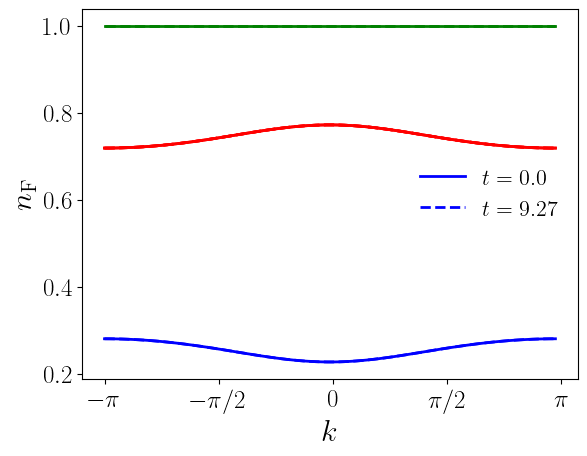

(PyCall.PyObject[PyObject <matplotlib.axis.XTick object at 0x7faef2f6f050>, PyObject <matplotlib.axis.XTick object at 0x7faef31ca720>, PyObject <matplotlib.axis.XTick object at 0x7faef33d9a90>, PyObject <matplotlib.axis.XTick object at 0x7faef385cda0>, PyObject <matplotlib.axis.XTick object at 0x7faef2ef30e0>], PyCall.PyObject[PyObject Text(-3.141592653589793, 0, '$-\\pi$'), PyObject Text(-1.5707963267948966, 0, '$-\\pi/2$'), PyObject Text(0.0, 0, '$0$'), PyObject Text(1.5707963267948966, 0, '$\\pi/2$'), PyObject Text(3.141592653589793, 0, '$\\pi$')])

In [155]:
t11 = 1
t22 = 80#length(15)
sol_t1 = ts[t11]
sol_t2 = ts[t22]
nf_t1  = imag.(GL_data[1,1,:,t11,t11])
nf_t2  = imag.(GL_data[1,1,:,t22,t22])


nf_t3  = imag.(GL_data[1,2,:,t11,t11])
nf_t4 = imag.(GL_data[1,2,:,t22,t22])


nf_t11  = imag.(GL_data[2,2,:,t11,t11])
nf_t22  = imag.(GL_data[2,2,:,t22,t22])




nf_t33  = imag.(GL_data[1,1,:,t11,t11]+ GL_data[2,2,:,t11,t11])
nf_t44  = imag.(GL_data[1,1,:,t22,t22]+ GL_data[2,2,:,t22,t22])

plot(ks, nf_t1; color="blue", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t2; color="blue", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")
legend(frameon=false)


plot(ks, nf_t11; color="red", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t22; color="red", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")

plot(ks, nf_t33; color="green", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t44; color="green", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")

plot(ks, nf_t11; color="red", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
plot(ks, nf_t22; color="red", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")


# plot(ks, nf_t3; color="black", linewidth=2, label="\$t = $(round(sol_t1, digits=2))\$", linestyle="-")
# plot(ks, nf_t4; color="yellow", linewidth=2, label="\$t = $(round(sol_t2, digits=2))\$", linestyle="--")


xlabel(raw"$k$")
ylabel(raw"$n_{\text{F}}$")
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])

#tight_layout()

In [156]:
#GL_data[10,10]
#GL_data

In [157]:
ts

499-element Vector{Float64}:
  0.0
  1.0e-6
  5.999999999999999e-6
  3.0999999999999995e-5
  0.00015599999999999997
  0.0007809999999999998
  0.0013434999999999996
  0.0018497499999999994
  0.004380999999999998
  0.01703724999999999
  0.028427874999999984
  0.08538099999999996
  0.13663881249999993
  ⋮
 78.13527030943514
 78.31760337758149
 78.49993755169652
 78.68258641462069
 78.86555986415443
 79.04861882263955
 79.23151812237579
 79.41417837823116
 79.59686093560741
 79.77994575857568
 79.96345479680524
 80.0

In [158]:
typeof(GL_data)

GreenFunction{ComplexF64, 5, Array{ComplexF64, 5}, SkewHermitian}

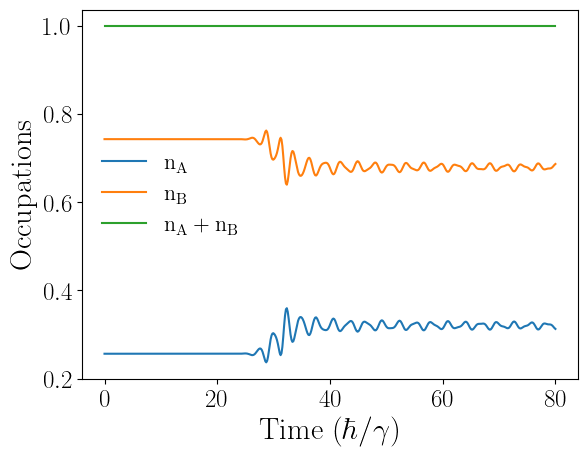

PyObject Text(37.06094617515048, 0.5, '$\\mathrm{Occupations}$')

In [20]:
n1 = [sum(imag.(GL_data[1,1,:,ti,ti]))/L for ti in 1:length(ts)]
n2 = [sum(imag.(GL_data[2,2,:,ti,ti]))/L for ti in 1:length(ts)]
plt.plot(ts,n1,label = L"\mathrm{n_A}")
plt.plot(ts,n2,label = L"\mathrm{n_B}")
plt.plot(ts,n1+n2, label = L"\mathrm{n_A} + \mathrm{n_B}")
#plt.ylim(-1,1)
plt.legend(frameon = false)
xlabel(raw"$\mathrm{Time}\ (\hbar/\gamma)$")
ylabel(raw"$\mathrm{Occupations}$")

In [160]:
# n1 = [sum(imag.(GL_data[1,1,:,ti,ti]))/L for ti in 1:length(ts)]
# n2 = [sum(imag.(GL_data[2,2,:,ti,ti]))/L for ti in 1:length(ts)]
# plt.plot(ts,n1)
# plt.plot(ts,n2)
# plt.plot(ts,n1+n2)
# #plt.ylim(-1,1)
# xlabel(raw"$\mathrm{Time}\ (\hbar/\gamma)$")
# ylabel(raw"$N(t)$")

In [161]:
#GL_data

In [162]:
#size(GL_data,3)

In [163]:
#ts

In [164]:
Nt = length(ts)
T = maximum(ts)
Δ1 = ts .- ts'
#ts' .- ts
# Windowing function W(t)
W = @.exp(-1.0 * (Δ1^2) / T^2)

GL_filt_11 = similar(GL_data)[1,1,:,:,:]
GG_filt_11 = similar(GG_data)[1,1,:,:,:]

for k in 1:size(GL_data,3)
    @views GL_filt_11[k, :, :] = (GL_data[1,1,k, :, :] .+ GL_data[2,2,k, :, :]   ).* W #+ GL_data[2,2,k, :, :] 
    @views GG_filt_11[k, :, :] = (GG_data[1,1,k, :, :] .+ GG_data[2,2,k, :, :]   ) .* W
end

# for k in 1:size(GL_data,3)
#     @views GL_filt_11[k, :, :] = (GL_data[1,1,k, :, :]    ).* W #+ GL_data[2,2,k, :, :] 
#     @views GG_filt_11[k, :, :] = (GG_data[1,1,k, :, :]    ) .* W
# end

In [165]:
#GL_filt_11

In [166]:
function wigner_transform_itp(x, ts::Vector; fourier = true, ts_lin = range(first(ts), last(ts); length = length(ts)))
    itp = interpolate((ts, ts), x, Gridded(Linear()))
    return wigner_transform([itp(t1, t2) for t1 in ts_lin, t2 in ts_lin]; ts = ts_lin, fourier = fourier)
end

wigner_transform_itp (generic function with 1 method)

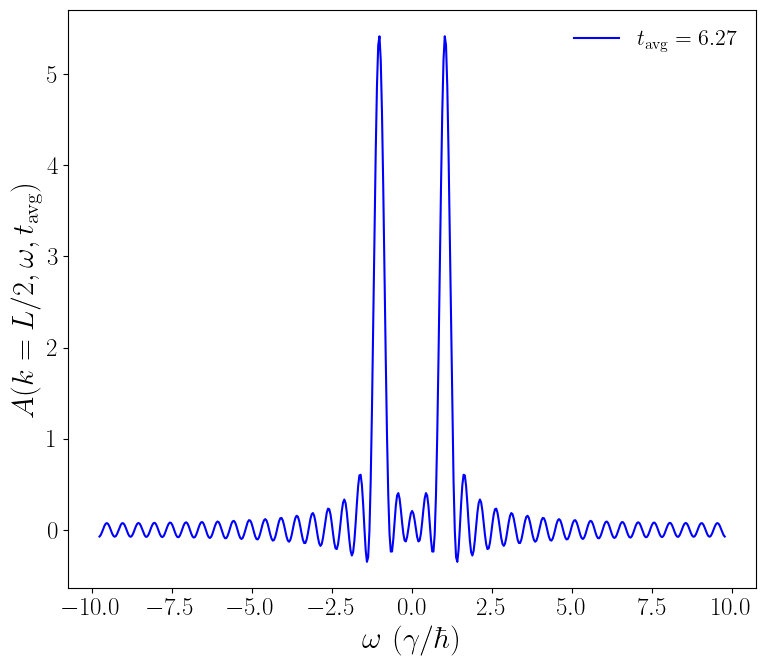

In [167]:
GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt_11[Int(L/2), :, :], ts; fourier=true)
GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt_11 .- GL_filt_11)[Int(L/2), :, :], ts; fourier=true)

F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
A_Wigner = - imag(GR_Wigner_FFT)/pi

t_avg = 40
t_avg_sol = tavg[t_avg]

# fig, ax = subplots(figsize=(8,7)) 
# xlabel(raw"$\omega \,\, (\gamma/\hbar)$")
# ylabel(raw"$F(k=L/2,\omega,t_{\text{avg}})$")
# plot(ωs, F_Wigner[:, t_avg], label="\$t_{\\text{avg}} = $(round(t_avg_sol, digits=2))\$", color="blue", linewidth=1.5)
# legend(frameon=false)
# tight_layout()
# savefig("figura2F.png", dpi=300)

fig, ax = subplots(figsize=(8,7)) 
xlabel(raw"$\omega \,\, (\gamma/\hbar)$")
ylabel("\$ A(k=L/2,\\omega,t_{\\text{avg}})\$")
plot(ωs, A_Wigner[:, t_avg], label="\$t_{\\text{avg}} = $(round(t_avg_sol, digits=2))\$", color="blue", linewidth=1.5)
legend(frameon=false)
tight_layout()

In [168]:
GL_Wigner_list = []
F_Wigner_list = []
A_Wigner_list = []

tavg_list = []
ωs_list = []

for k in 1:L
    GL_Wigner_FFT, (ωs, tavg) = wigner_transform_itp(GL_filt_11[k, :, :], ts; fourier=true)
    GR_Wigner_FFT, (ωs, tavg) = wigner_transform_itp((GG_filt_11 - GL_filt_11)[k, :, :], ts; fourier=true)
    F_Wigner = - 0.5 * imag(GL_Wigner_FFT) ./ (imag(GR_Wigner_FFT))
    A_Wigner = - imag(GR_Wigner_FFT)/pi

    push!(GL_Wigner_list, GL_Wigner_FFT)
    push!(F_Wigner_list, F_Wigner)
    push!(A_Wigner_list, A_Wigner)
    
    push!(tavg_list, tavg)
    push!(ωs_list, ωs)
end

In [169]:
dim_tavg = size(GL_data)[4]

GL_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
F_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)
A_Wigner_tensor = zeros(ComplexF64, L, dim_tavg, dim_tavg)

for i in 1:L
    for k in 1:dim_tavg
        for j in 1:dim_tavg
            GL_Wigner_tensor[i,j,k] = GL_Wigner_list[i][j,k]
            F_Wigner_tensor[i,j,k] = F_Wigner_list[i][j,k]
            A_Wigner_tensor[i,j,k] = A_Wigner_list[i][j,k]
        end
    end
end

In [170]:
@tullio GL_Wigner_sumk[i_ωs,i_tavg] := GL_Wigner_tensor[k,i_ωs,i_tavg];
@tullio A_Wigner_sumk[i_ωs,i_tavg] := A_Wigner_tensor[k,i_ωs,i_tavg];

GL_Wigner_sumk = GL_Wigner_sumk./L
A_Wigner_sumk = A_Wigner_sumk./L
F_Wigner_sumk = (1/(2pi)) * imag.(GL_Wigner_sumk) ./ A_Wigner_sumk;

In [78]:
# ΞG = GreenFunction(zeros(ComplexF64, L, 1, 1), SkewHermitian) ###
# ΣL_F = GreenFunction(zeros(ComplexF64, 2, 2, L, 1, 1), SkewHermitian)

12.2519060962297


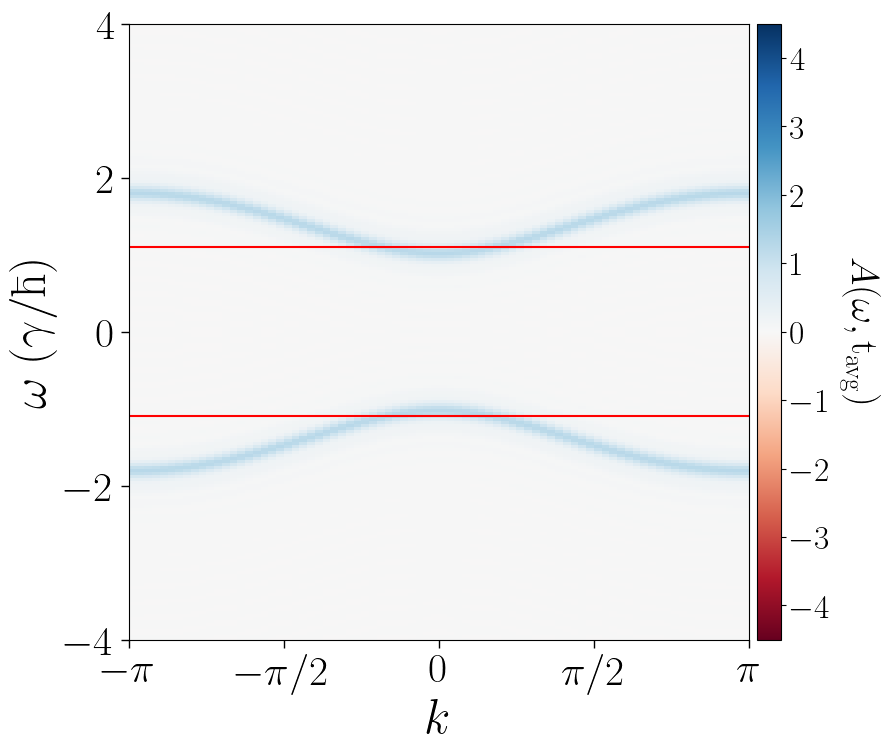

In [171]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

# t_avg1 = 210
# t_avg2 = 499
# t_avg3 = 504
# t_avg4 = 602

fs = 30
t_avg = 100
t_avg_sol = ts[t_avg]
println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = real.(transpose(A_Wigner_tensor[:,end:-1:1,t_avg]))/(2pi)

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-4.5, vmax=4.5)
plt.axhline(2.2/2,color="red")
plt.axhline(-2.2/2,color="red")
plt.ylim(-4,4)
axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$A\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)



In [172]:
A_Wigner_tensor

80×499×499 Array{ComplexF64, 3}:
[:, :, 1] =
 0.204536+0.0im  0.204536+0.0im  …  0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im  …  0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im  …  0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
 0.204536+0.0im  0.204536+0.0im     0.204536+0.0im  0.204536+0.0im
         ⋮                       ⋱                  
 0.204536+0.0im  0.204536+0.0im

In [173]:
datats["sol"].t[130]

16.855782022350628

In [189]:
2pi/3

2.0943951023931953

55.15952327593222


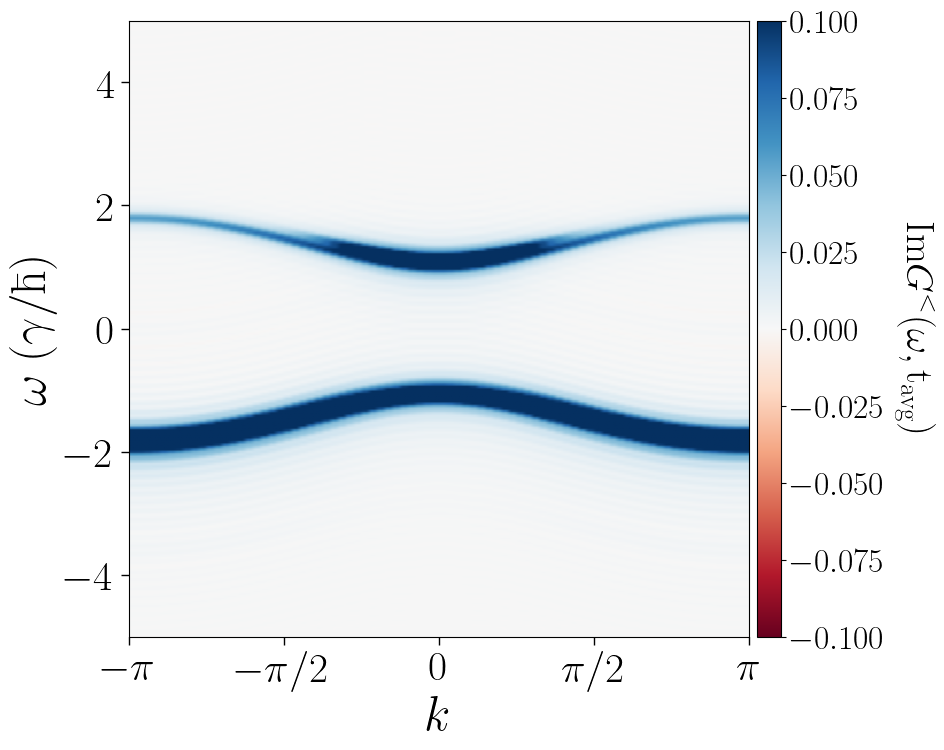

In [200]:
fig,axs=plt.subplots(1,1,figsize=(8,8))

fs = 30
t_avg = 360
t_avg_sol = ts[t_avg]

println(t_avg_sol)

cmap = plt.get_cmap("RdBu", 3024)

datt = imag.(transpose(GL_Wigner_tensor[:,end:-1:1,t_avg])/(40))

t1x = -pi
t2x = pi
t1y = ωs[1]
t2y = ωs[end]
#plt.ylim(-10,10)

img = axs.imshow(datt, aspect="auto", cmap=cmap, extent=[t1x,t2x,t1y,t2y], vmin=-0.1, vmax=0.1)

axs.set_xlabel(raw"$k$", fontsize=fs+5)
axs.set_ylabel(raw"$\mathrm{\omega \; (\gamma/\hbar) }$", fontsize=fs+5)
axs.tick_params(axis="both", which="both", labelsize=fs, direction="out", length=6, width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
#plt.plot(ks, ϵ_k.(ks), color="yellow", ls="--", linewidth=2)
plt.ylim(-5,5)
box = axs.get_position() 
cbar_ax = fig.add_axes([box.x1 + 0.01, box.y0, 0.03, box.height])
cbar = fig.colorbar(img, cax=cbar_ax)
cbar.ax.tick_params(labelsize=fs-6)
cbar.set_label(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$", fontsize=fs-2,rotation=270,labelpad=35)

In [95]:
tavg

0.0:0.1596806387225549:80.0

15.112537767099639


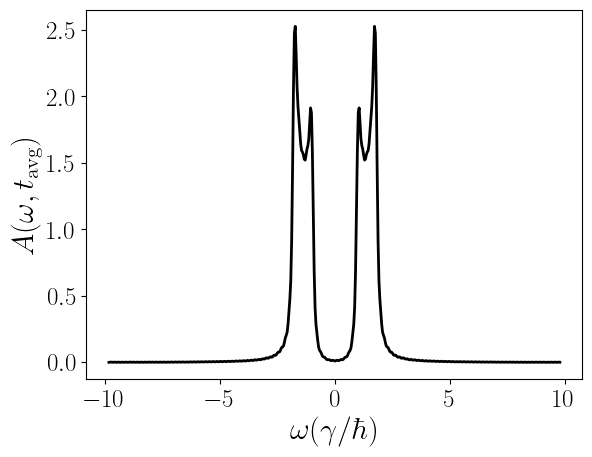

In [96]:
t_avg = 120#190#300
t_avg_sol = ts[t_avg]

plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$A(\omega,t_{\text{avg}})$")
println(t_avg_sol)
#plt.ylim(-0.01,0.2)
#plt.ylim(0,0.05)
#plt.show()

In [97]:
A_Wigner_sumk[:,80]

502-element Vector{ComplexF64}:
  -0.005754044035439864 + 0.0im
 -0.0029654535398593927 + 0.0im
  0.0028589321587073314 + 0.0im
   0.006413834160793025 + 0.0im
   0.004470646005084474 + 0.0im
 -0.0011776156268936274 + 0.0im
  -0.005354551085368408 + 0.0im
  -0.004226774720977246 + 0.0im
   0.001195386989408864 + 0.0im
     0.0059788750928638 + 0.0im
   0.005771107284524574 + 0.0im
  0.0007753172200742393 + 0.0im
   -0.00443209051004155 + 0.0im
                        ⋮
 -0.0044320907811783205 + 0.0im
  0.0007753169259058728 + 0.0im
   0.005771107219571388 + 0.0im
  0.0059788753126517906 + 0.0im
   0.001195387305285523 + 0.0im
  -0.004226774579936083 + 0.0im
  -0.005354551240021332 + 0.0im
 -0.0011776159444852282 + 0.0im
   0.004470645796979572 + 0.0im
   0.006413834240619307 + 0.0im
  0.0028589324579379356 + 0.0im
 -0.0029654532779031934 + 0.0im

In [98]:
sum(abs.(real.(A_Wigner_sumk[:,80])))#/40
#sum(abs.(imag.(GL_Wigner_sumk[:,t_avg]))/pi)/40

101.36856397325828

In [99]:
# t_avg = 150#300
# t_avg_sol = tavg[t_avg]

# plot(ωs, real.(A_Wigner_sumk[:,t_avg]), color="black", linewidth=2)
# xlabel(raw"$\omega(\gamma/\hbar)$")
# ylabel(raw"$A(\omega,t_{\text{avg}})$")
# println(t_avg_sol)
# plt.xlim(-6,6)
# #plt.ylim(0,0.05)
# plt.show()

33.852295409181636


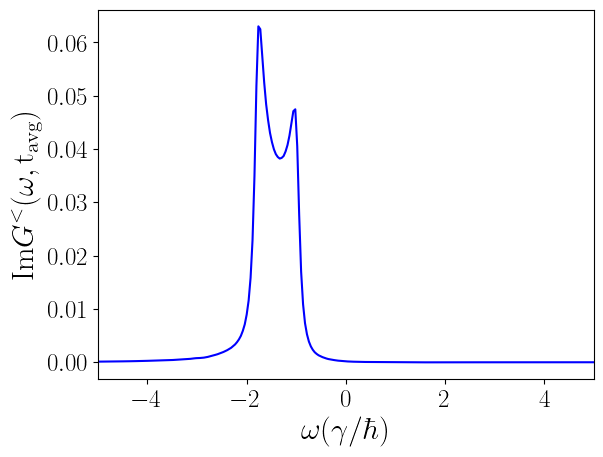

In [143]:
t_avg = 213
t_avg_sol = tavg[t_avg]

plot(ωs, imag.(GL_Wigner_sumk[:,t_avg])/pi/(40), color="blue", linewidth=1.5)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$\text{Im}G^{<}\mathrm{(\omega,t_{\text{avg}})}$")
plt.xlim(-5,5)
#plt.ylim(0,0.1)
println(t_avg_sol)
plt.show()

34.332180066235246


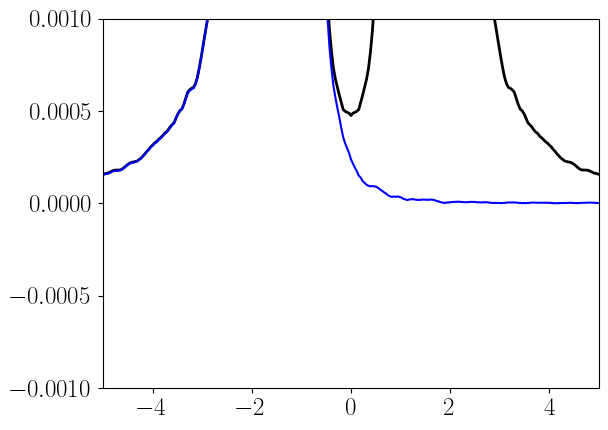

(-0.001, 0.001)

In [149]:
t_avg = 240#165#360#213#110#300
t_avg_sol = ts[t_avg]
println(t_avg_sol)

plot(ωs, real.(A_Wigner_sumk[:,t_avg])/(40), color="black", linewidth=2)
plot(ωs, imag.(GL_Wigner_sumk[:,t_avg])/pi/(40), color="blue", linewidth=1.5)
plt.xlim(-5,5)
plt.ylim(-0.001,0.001)

In [103]:
#model = ModelElectronBath()

In [109]:
ωs

-9.837111996552999:0.03919168126116732:9.79792031529183

34.332180066235246


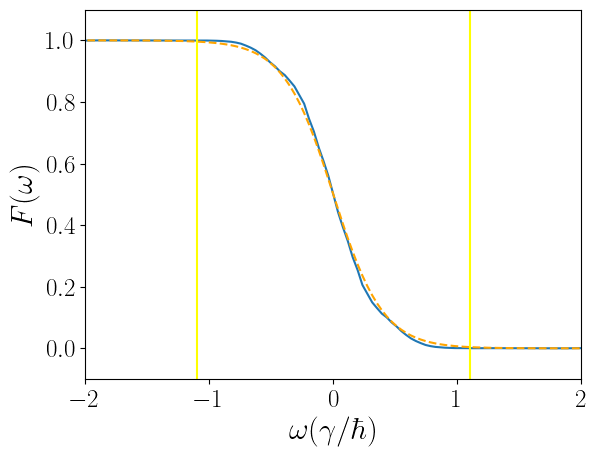

In [142]:
t_avg = 240
t_avg_sol = ts[t_avg]
println(t_avg_sol)
δ = 1e-3
A_col   = real.(A_Wigner_sumk[:, t_avg])
GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# Máscara de puntos "seguros"
mask = abs.(A_col) .> δ

mask2 = 0.0 .< GL_im./A_col .< 1.0

ratio1 = fill(NaN, length(A_col))

ratio1[mask2] .= GL_im[mask2] ./ (A_col[mask2])

#plt.scatter(ωs,ratio1)

plt.plot(ωs,GL_im./A_col)

plt.plot(ωs,fermi.(ωs, 0.2),color="orange",ls="--")#ls="-o")

# t_avg = 180
# t_avg_sol = tavg[t_avg]
# println(t_avg_sol)
# δ = 1e-6
# A_col   = real.(A_Wigner_sumk[:, t_avg])
# GL_im   = imag.(GL_Wigner_sumk[:, t_avg])/pi
# # Máscara de puntos "seguros"
# mask = abs.(A_col) .> δ
# ratio = fill(NaN, length(A_col))
# ratio[mask] .= GL_im[mask] ./ A_col[mask]

# plt.plot(ωs,ratio)
plt.xlim(-2,2)
#plt.ylim(-5,5)
plt.axvline(2.5,color="yellow")
plt.axvline(-2.5,color="yellow")

plt.axvline(2.2/2,color="yellow")
plt.axvline(-2.2/2,color="yellow")

plt.ylim(-0.1,1.1)
#plt.xlim(-1.0,1.0)
#plt.xlim(-5.2,5.2)
xlabel(raw"$\omega(\gamma/\hbar)$")
ylabel(raw"$F\mathrm{(\omega )}$")
plt.savefig("F.png")

In [1483]:
# mask = abs.(A_col) .> δ

# mask2 = 0.0 .< abs.(GL_im./A_col) .< 1.0

In [1484]:
#mask

In [1485]:
#mask2

In [207]:
# fermi.(ωs;model=model)
# model.T

In [58]:
methods(fermi)

# 2 methods for generic function "fermi" from Main:
 [1] fermi(ϵ::Float64, T::Float64)
     @ In[56]:34
 [2] fermi(ϵ::Float64, model::ModelElectronBath)
     @ In[56]:26